# E-Commerce Recommendation Engine: Model Training & Evaluation

This notebook documents the process of exploring data, building, and training a Deep Learning model for product recommendation using PyTorch. 
The dataset used is the "Online Retail" dataset from the UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset

## 1. Data Loading and Cleaning
We download the dataset and filter out invalid transactions (e.g., negative quantities, missing CustomerID).

In [2]:
parquet_file = "dataset.parquet"
pickle_file = "metadata.pkl"

if not os.path.exists(parquet_file):
    print("Downloading dataset...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    df = pd.read_excel(url)

    # Data Cleaning
    df_clean = df.dropna(subset=["CustomerID"]).copy()
    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean["UnitPrice"] > 0)]
    df_clean['StockCode'] = df_clean['StockCode'].astype(str)
    
    # Keep only valid product codes (5 digits)
    df_clean = df_clean[df_clean['StockCode'].str.match(r'^\d{5}')]
    df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
    df_clean = df_clean.sort_values(['CustomerID', 'InvoiceDate'])
    
    df_clean.to_parquet(parquet_file, engine='pyarrow')
    print("Dataset cleaned and saved!")
else:
    print("Loading data from cache...")
    df = pd.read_parquet(parquet_file)

Loading data from cache...


## 2. Exploratory Data Analysis (EDA)
We analyze the distribution of customer interactions with products to understand the degree of sparsity in our interaction matrix.

Average interactions per client: 91.45
Max interactions: 7838
Median: 41.0


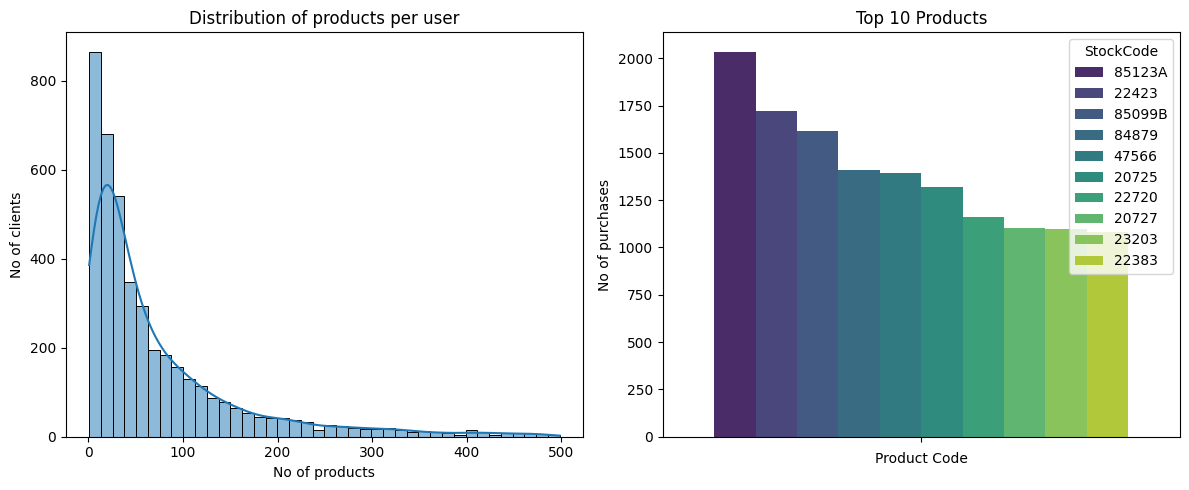

In [3]:
client_interactions = df.groupby('CustomerID').size()
    
print(f"Average interactions per client: {client_interactions.mean():.2f}")
print(f"Max interactions: {client_interactions.max()}")
print(f"Median: {client_interactions.median()}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(client_interactions[client_interactions < 500], bins=40, kde=True, legend=False)
plt.title("Distribution of products per user")
plt.xlabel("No of products")
plt.ylabel("No of clients")

plt.subplot(1, 2, 2)
top_products = df['StockCode'].value_counts().head(10)
sns.barplot(hue=top_products.index, y=top_products.values, palette='viridis')
plt.title("Top 10 Products")
plt.xlabel("Product Code")
plt.ylabel("No of purchases")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## 3. Deep Learning Architecture (PyTorch)
To keep this notebook self-contained, we define the `Dataset` and `Model` classes here. 
We use an architecture based on Embeddings (to capture latent similarities) followed by Multi-Layer Perceptron (MLP) layers to predict the probability of interaction.

In [4]:
class Data(Dataset):
    def __init__(self, users, items, total_items, negative_samples=0):
        self.users = users
        self.items = items
        self.total_items = total_items
        self.negative_samples = negative_samples

    def __len__(self):
        return len(self.users)

    def __getitem__(self, index):
        user = self.users[index]
        positive_item = self.items[index]
        negative_items = []

        for _ in range(self.negative_samples):
            item = random.randint(0, self.total_items - 1)
            negative_items.append(item)

        return {
            'user': torch.tensor(user, dtype=torch.long),
            'positive_item': torch.tensor(positive_item, dtype=torch.long),
            'negative_items': torch.tensor(negative_items, dtype=torch.long)
        }

class Model(nn.Module):
    def __init__(self, users, items, embedding_dim=64):
        super(Model, self).__init__()
        self.user_embedding = nn.Embedding(users, embedding_dim)
        self.item_embedding = nn.Embedding(items, embedding_dim)

        self.layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, user_index, item_index):
        user_vector = self.user_embedding(user_index)
        item_vector = self.item_embedding(item_index)
        vector = torch.cat([user_vector, item_vector], dim=1)
        score = self.layers(vector)
        return score.squeeze()

## 4. Data Preparation for Training
We split the data temporally (Train / Val / Test) using the `cumcount` function to predict the latest purchase based on previous ones. We also encode the IDs using `LabelEncoder`.

In [5]:
frequent_clients = client_interactions[client_interactions >= 3].index
df_dl = df[df['CustomerID'].isin(frequent_clients)].copy()
df_dl = df_dl.sort_values(['CustomerID', 'InvoiceDate'])
df_dl['Ordering'] = df_dl.groupby('CustomerID').cumcount(ascending=False)

test_set = df_dl[df_dl['Ordering'] == 0].copy()
val_set = df_dl[df_dl['Ordering'] == 1].copy()
train_set = df_dl[df_dl['Ordering'] > 1].copy()

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df_dl['user_idx'] = user_encoder.fit_transform(df_dl['CustomerID'])
df_dl['item_idx'] = item_encoder.fit_transform(df_dl['StockCode'])

train_set['user_idx'] = user_encoder.transform(train_set['CustomerID'])
train_set['item_idx'] = item_encoder.transform(train_set['StockCode'])

test_set['user_idx'] = user_encoder.transform(test_set['CustomerID'])
test_set['item_idx'] = item_encoder.transform(test_set['StockCode'])

num_users = df_dl['user_idx'].nunique()
num_items = df_dl['item_idx'].nunique()

print(f"Unique users (frequent): {num_users}")
print(f"Unique products: {num_items}")

Unique users (frequent): 4211
Unique products: 3659


## 5. Model Training
The model is trained using `BCELoss` (Binary Cross Entropy) since we treat the problem as binary classification: purchased (1) or not purchased (0).
We utilize Negative Sampling (4 negative examples for each positive interaction).

In [8]:
train_dataset = Data(
    users=train_set['user_idx'].values,
    items=train_set['item_idx'].values,
    total_items=num_items,
    negative_samples=4
)

data_loader = DataLoader(train_dataset, batch_size=8192, shuffle=True)

model = Model(users=num_users, items=num_items, embedding_dim=64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.015)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in data_loader:
        users = batch['user'].to(device)
        item_pos = batch['positive_item'].to(device)
        item_neg = batch['negative_items'].to(device)
        
        num_negatives = item_neg.size(1)

        pos_scores = model(users, item_pos)
        pos_labels = torch.ones_like(pos_scores)

        users_expanded = users.unsqueeze(1).repeat(1, num_negatives).view(-1)
        item_neg_flat = item_neg.view(-1)

        neg_scores = model(users_expanded, item_neg_flat)
        neg_labels = torch.zeros_like(neg_scores)

        all_scores = torch.cat([pos_scores, neg_scores])
        all_labels = torch.cat([pos_labels, neg_labels])

        loss = criterion(all_scores, all_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch 1/10 | Loss: 0.4399
Epoch 2/10 | Loss: 0.3920
Epoch 3/10 | Loss: 0.3850
Epoch 4/10 | Loss: 0.3810
Epoch 5/10 | Loss: 0.3760
Epoch 6/10 | Loss: 0.3696
Epoch 7/10 | Loss: 0.3610
Epoch 8/10 | Loss: 0.3536
Epoch 9/10 | Loss: 0.3475
Epoch 10/10 | Loss: 0.3420

Training complete!


## 6. Model Evaluation (Hit Ratio @ 10)
For evaluation, we test whether the actual product the client purchased (hidden from the model) is present in the top 10 recommendations generated by the model, compared against 99 randomly selected items.

In [9]:
model.eval()

K = 10
hits = 0
total_users = 0

print("Starting Final Evaluation (Hit Ratio @ 10)...")

test_users = test_set['user_idx'].unique()[:500]

with torch.no_grad():
    for u in test_users:
        item_real = test_set[test_set['user_idx'] == u]['item_idx'].values[0]
        items_fake = random.sample(range(num_items), 99)

        if item_real in items_fake:
            items_fake.remove(item_real)
            items_fake.append(random.randint(0, num_items - 1))

        items_candidates = [item_real] + items_fake
        user_tensor = torch.tensor([u] * 100).to(device)
        items_tensor = torch.tensor(items_candidates).to(device)

        scores = model(user_tensor, items_tensor).cpu().numpy()
        top_k_indices = scores.argsort()[-K:]

        if 0 in top_k_indices:
            hits += 1
        total_users += 1

hit_ratio = (hits / total_users) * 100
print(f"\nFinal Result - HR@{K}: {hit_ratio:.2f}%")
print(f"For {hit_ratio:.0f}% of users, the model correctly ranked the purchased item in the Top {K} recommendations.")

Starting Final Evaluation (Hit Ratio @ 10)...

Final Result - HR@10: 58.20%
For 58% of users, the model correctly ranked the purchased item in the Top 10 recommendations.
